# Data Cleaning for CVAT Annotation

notebook นี้ทำความสะอาด dataset ก่อนส่งเข้า CVAT แบ่งภาพตามความพร้อมของ panel/defect annotation และตัด exact duplicate, ภาพหิมะ และภาพที่ไม่มี annotation ออก

ถ้ามี source manifest จาก pipeline เดิมจะโหลดมาใช้ทันที หากเริ่ม pipeline ใหม่ notebook จะสร้างข้อมูลตั้งต้นจาก EDA outputs ก่อน แล้วจึงใช้กฎ cleaning เดิมเพื่อสร้าง A, A_partial, B และ C


## Setup


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from multiprocessing import Pool, cpu_count
import ast
import hashlib
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DRIVE_BASE = Path('/content/drive/MyDrive/ai builders/dataset')
EDA_CACHE = DRIVE_BASE / 'eda_cache'
SOURCE_BASE = DRIVE_BASE / 'cleaned_v3'
OUTPUT_BASE = DRIVE_BASE / 'cleaned_v4'

INPUT_MANIFEST_PATH = SOURCE_BASE / 'final_manifest_v2.csv'
INPUT_IMAGES_PATH = EDA_CACHE / 'unified_images.csv'
INPUT_ANNOTATIONS_PATH = EDA_CACHE / 'unified_annotations.csv'
INPUT_SKIPPED_PATH = EDA_CACHE / 'skipped_annotations.csv'
SOURCE_MANIFEST_CACHE_PATH = EDA_CACHE / 'cleaning_source_manifest.csv'
MD5_CACHE_PATH = EDA_CACHE / 'image_md5.csv'

OUTPUT_MANIFEST_PATH = OUTPUT_BASE / 'final_manifest_v4.csv'
OUTPUT_ANNOTATIONS_PATH = OUTPUT_BASE / 'clean_annotations.csv'
OUTPUT_SUMMARY_PATH = OUTPUT_BASE / 'summary_v4.json'

PANEL_CLASSES = {'panel_clean', 'panel_defective'}
DEFECT_CLASSES = {'dust', 'bird_drop', 'physical_damage', 'leaf'}
BBOX_DATASETS = {'IA-Cobotics', 'bird_dust_leaf'}
KEPT_CATEGORIES = {'A', 'A_partial', 'B', 'C'}
ALL_CATEGORIES = ['A', 'A_partial', 'B', 'C', 'DUPLICATE', 'EMPTY', 'SNOW_EXCLUDED']

OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path('/content/drive/MyDrive/ai builders/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output folder: {OUTPUT_BASE}')


Mounted at /content/drive
Output folder: /content/drive/MyDrive/ai builders/dataset/cleaned_v4


## source manifest


In [2]:
if not INPUT_ANNOTATIONS_PATH.exists():
    raise FileNotFoundError(
        f'Missing EDA annotations: {INPUT_ANNOTATIONS_PATH}. '
        'Run 02_eda.ipynb through the unified CSV export cell first.'
    )


def ensure_image_id(dataframe, dataframe_name):
    """Return a copy with the dataset-scoped image identifier used downstream."""
    dataframe = dataframe.copy()
    if 'image_id' not in dataframe.columns:
        required = {'dataset', 'image_stem'}
        if not required.issubset(dataframe.columns):
            raise ValueError(
                f'{dataframe_name} cannot rebuild image_id. '
                f'Missing columns: {sorted(required - set(dataframe.columns))}'
            )
        dataframe['image_id'] = (
            dataframe['dataset'].astype(str)
            + '::'
            + dataframe['image_stem'].astype(str)
        )
        print(f'Rebuilt image_id for {dataframe_name}')
    return dataframe


annotations = ensure_image_id(
    pd.read_csv(INPUT_ANNOTATIONS_PATH, low_memory=False),
    'unified_annotations',
)

if INPUT_MANIFEST_PATH.exists():
    # Preserve the original notebook behavior when the upstream artifact exists.
    input_manifest = pd.read_csv(INPUT_MANIFEST_PATH, low_memory=False)
    active_input_manifest_path = INPUT_MANIFEST_PATH
    print(f'Loaded existing source manifest: {INPUT_MANIFEST_PATH}')
else:
    # Fresh pipeline fallback: reproduce only the upstream MD5 and Snow fields
    # consumed by the current A/A_partial/B/C cleaning logic.
    required_eda_outputs = [INPUT_IMAGES_PATH, INPUT_SKIPPED_PATH]
    missing_eda_outputs = [
        path for path in required_eda_outputs if not path.exists()
    ]
    if missing_eda_outputs:
        missing_text = '\n'.join(
            f'  - {path}' for path in missing_eda_outputs
        )
        raise FileNotFoundError(
            'The source manifest is unavailable and these EDA outputs '
            f'are missing:\n{missing_text}\n'
            'Run 02_eda.ipynb through the unified CSV export cell first.'
        )

    images_df = ensure_image_id(
        pd.read_csv(INPUT_IMAGES_PATH, low_memory=False),
        'unified_images',
    )
    skipped_annotations = ensure_image_id(
        pd.read_csv(INPUT_SKIPPED_PATH, low_memory=False),
        'skipped_annotations',
    )

    required_image_columns = {'image_id', 'dataset', 'split', 'image_path'}
    required_annotation_columns = {
        'image_id',
        'class_unified',
        'format',
        'coords',
        'area_normalized',
    }
    required_skipped_columns = {'image_id', 'class_orig'}
    missing_image_columns = required_image_columns - set(images_df.columns)
    missing_annotation_columns = (
        required_annotation_columns - set(annotations.columns)
    )
    missing_skipped_columns = (
        required_skipped_columns - set(skipped_annotations.columns)
    )
    if (
        missing_image_columns
        or missing_annotation_columns
        or missing_skipped_columns
    ):
        raise ValueError(
            'EDA outputs have an unexpected schema: '
            f'images={sorted(missing_image_columns)}, '
            f'annotations={sorted(missing_annotation_columns)}, '
            f'skipped={sorted(missing_skipped_columns)}'
        )

    polygon_datasets = {'solar-panel-o6dwf', 'solar-panel-b1cmz'}
    dataset_size_rank = {
        'IA-Cobotics': 302,
        'bird_dust_leaf': 500,
        'solar-panel-b1cmz': 721,
        'solar-panel-o6dwf': 1723,
    }

    def calculate_md5(image_path):
        """Return the MD5 digest used to identify byte-identical images."""
        try:
            digest = hashlib.md5()
            with open(image_path, 'rb') as handle:
                for chunk in iter(
                    lambda: handle.read(1024 * 1024),
                    b'',
                ):
                    digest.update(chunk)
            return digest.hexdigest()
        except Exception as exc:
            return f'ERROR::{type(exc).__name__}::{exc}'

    def md5_worker(image_path):
        return str(image_path), calculate_md5(image_path)

    def calculate_or_load_md5(images, force=False):
        """Hash uncached paths in parallel, with a serial fallback."""
        cached = pd.DataFrame(columns=['image_path', 'md5_hash'])
        if MD5_CACHE_PATH.exists() and not force:
            cached = pd.read_csv(MD5_CACHE_PATH)
            if not {'image_path', 'md5_hash'}.issubset(cached.columns):
                cached = pd.DataFrame(
                    columns=['image_path', 'md5_hash']
                )

        cached = cached.drop_duplicates('image_path', keep='last')
        cached_paths = set(cached['image_path'].astype(str))
        image_paths = (
            images['image_path'].dropna().astype(str).unique().tolist()
        )
        missing_paths = [
            image_path
            for image_path in image_paths
            if image_path not in cached_paths
        ]

        if missing_paths:
            print(
                f'Calculating MD5 for '
                f'{len(missing_paths):,} uncached images...'
            )
            worker_count = max(1, min(cpu_count(), 8))
            try:
                with Pool(processes=worker_count) as pool:
                    results = list(
                        tqdm(
                            pool.imap_unordered(
                                md5_worker,
                                missing_paths,
                            ),
                            total=len(missing_paths),
                            desc='MD5 exact duplicate scan',
                        )
                    )
            except Exception as exc:
                print(
                    'Parallel MD5 scan failed; '
                    f'using serial fallback: {exc}'
                )
                results = [
                    md5_worker(image_path)
                    for image_path in tqdm(
                        missing_paths,
                        desc='MD5 exact duplicate scan',
                    )
                ]

            cached = pd.concat(
                [
                    cached,
                    pd.DataFrame(
                        results,
                        columns=['image_path', 'md5_hash'],
                    ),
                ],
                ignore_index=True,
            ).drop_duplicates('image_path', keep='last')
            cached.to_csv(MD5_CACHE_PATH, index=False)
            print(f'Saved MD5 cache: {MD5_CACHE_PATH}')
        else:
            print(f'Loaded complete MD5 cache: {MD5_CACHE_PATH}')

        return cached[cached['image_path'].isin(image_paths)].copy()

    def build_source_manifest(images, annotation_rows, hashes):
        """Build the upstream fields retained by the current cleaning step."""
        annotation_counts = annotation_rows.groupby('image_id').size()
        source_manifest = images.merge(
            hashes,
            on='image_path',
            how='left',
        ).copy()
        source_manifest['annotation_count'] = (
            source_manifest['image_id']
            .map(annotation_counts)
            .fillna(0)
            .astype(int)
        )
        source_manifest['format_priority'] = (
            source_manifest['dataset'].isin(polygon_datasets).astype(int)
        )
        source_manifest['dataset_size'] = (
            source_manifest['dataset']
            .map(dataset_size_rank)
            .fillna(10**9)
            .astype(int)
        )
        source_manifest['is_hash_error'] = (
            source_manifest['md5_hash'].isna()
            | source_manifest['md5_hash']
            .astype(str)
            .str.startswith('ERROR::')
        )

        valid_manifest = source_manifest[
            ~source_manifest['is_hash_error']
        ]
        duplicate_group_sizes = (
            valid_manifest.groupby('md5_hash')
            .size()
            .rename('duplicate_group_size')
        )
        duplicate_hashes = sorted(
            duplicate_group_sizes[duplicate_group_sizes > 1].index
        )
        duplicate_group_ids = {
            md5_hash: f'md5dup_{index:04d}'
            for index, md5_hash in enumerate(
                duplicate_hashes,
                start=1,
            )
        }

        source_manifest['duplicate_group_id'] = (
            source_manifest['md5_hash'].map(duplicate_group_ids)
        )
        source_manifest['is_exact_duplicate'] = False
        source_manifest['is_duplicate'] = False

        duplicate_rows = source_manifest[
            source_manifest['duplicate_group_id'].notna()
        ]
        for _, duplicate_group in duplicate_rows.groupby('md5_hash'):
            ranked = duplicate_group.sort_values(
                [
                    'format_priority',
                    'annotation_count',
                    'dataset_size',
                    'image_id',
                ],
                ascending=[False, False, True, True],
            )
            duplicate_indices = ranked.index[1:]
            source_manifest.loc[
                duplicate_indices,
                ['is_exact_duplicate', 'is_duplicate'],
            ] = True

        source_manifest['source_dataset'] = source_manifest['dataset']
        source_manifest['original_path'] = source_manifest['image_path']
        source_manifest['original_split'] = source_manifest['split']
        return source_manifest

    md5_df = calculate_or_load_md5(images_df)
    source_manifest = build_source_manifest(
        images_df,
        annotations,
        md5_df,
    )

    snow_ids = set(
        skipped_annotations.loc[
            skipped_annotations['class_orig']
            .astype(str)
            .str.lower()
            .eq('snow'),
            'image_id',
        ]
        .dropna()
        .astype(str)
    )
    source_manifest['snow_image'] = (
        source_manifest['image_id'].astype(str).isin(snow_ids)
    )

    source_manifest_columns = [
        'image_id',
        'source_dataset',
        'original_path',
        'original_split',
        'md5_hash',
        'duplicate_group_id',
        'is_duplicate',
        'is_exact_duplicate',
        'snow_image',
    ]
    input_manifest = source_manifest[source_manifest_columns].copy()
    input_manifest.to_csv(SOURCE_MANIFEST_CACHE_PATH, index=False)
    active_input_manifest_path = SOURCE_MANIFEST_CACHE_PATH

    print('Built source manifest from EDA outputs')
    print(f'  Images:           {len(input_manifest):,}')
    print(
        f'  Exact duplicates: '
        f'{input_manifest["is_exact_duplicate"].sum():,}'
    )
    print(f'  Snow images:      {input_manifest["snow_image"].sum():,}')
    print(f'  Cached manifest:  {SOURCE_MANIFEST_CACHE_PATH}')

print(f'Input manifest rows: {len(input_manifest):,}')
print(f'Annotation rows:     {len(annotations):,}')


Rebuilt image_id for unified_annotations
Rebuilt image_id for unified_images
Rebuilt image_id for skipped_annotations
Calculating MD5 for 3,246 uncached images...


MD5 exact duplicate scan:   0%|          | 0/3246 [00:00<?, ?it/s]

Saved MD5 cache: /content/drive/MyDrive/ai builders/dataset/eda_cache/image_md5.csv
Built source manifest from EDA outputs
  Images:           3,246
  Exact duplicates: 418
  Snow images:      125
  Cached manifest:  /content/drive/MyDrive/ai builders/dataset/eda_cache/cleaning_source_manifest.csv
Input manifest rows: 3,246
Annotation rows:     35,037


## จัด schema และชนิดข้อมูล


In [3]:
def normalize_bool(series):
    if series.dtype == bool:
        return series.fillna(False).astype(bool)

    normalized = series.fillna(False).astype(str).str.strip().str.lower()
    unexpected = set(normalized.unique()) - {'true', 'false'}
    if unexpected:
        raise ValueError(f'Unexpected boolean values: {sorted(unexpected)}')
    return normalized.eq('true')


input_manifest = input_manifest.copy()
annotations = annotations.copy()

if 'source_dataset' not in input_manifest.columns and 'dataset' in input_manifest.columns:
    input_manifest['source_dataset'] = input_manifest['dataset']
if 'original_path' not in input_manifest.columns and 'image_path' in input_manifest.columns:
    input_manifest['original_path'] = input_manifest['image_path']
if 'original_split' not in input_manifest.columns:
    input_manifest['original_split'] = ''
if 'is_exact_duplicate' not in input_manifest.columns:
    input_manifest['is_exact_duplicate'] = input_manifest.get('is_duplicate', False)
if 'snow_image' not in input_manifest.columns:
    input_manifest['snow_image'] = False

if 'source_dataset' not in annotations.columns and 'dataset' in annotations.columns:
    annotations['source_dataset'] = annotations['dataset']
if 'class_original' not in annotations.columns and 'class_orig' in annotations.columns:
    annotations['class_original'] = annotations['class_orig']
if 'coords_normalized' not in annotations.columns and 'coords' in annotations.columns:
    annotations['coords_normalized'] = annotations['coords']

if 'image_id' not in annotations.columns:
    annotations['image_id'] = annotations['dataset'].astype(str) + '::' + annotations['image_stem'].astype(str)
    print('Rebuilt image_id for annotations from dataset + image_stem')

if 'annotation_id' not in annotations.columns and {'image_id', 'line_no'}.issubset(annotations.columns):
    annotations['annotation_id'] = annotations['image_id'].astype(str) + '::line_' + annotations['line_no'].astype(str)
    print('Rebuilt annotation_id for annotations from image_id + line_no')

required_manifest_cols = {'image_id', 'source_dataset', 'original_path', 'md5_hash', 'is_exact_duplicate', 'snow_image'}
missing_manifest_cols = required_manifest_cols - set(input_manifest.columns)
if missing_manifest_cols:
    raise ValueError(f'Manifest missing required columns: {sorted(missing_manifest_cols)}')

required_annotation_cols = {'image_id', 'class_unified', 'coords_normalized'}
missing_annotation_cols = required_annotation_cols - set(annotations.columns)
if missing_annotation_cols:
    raise ValueError(f'Annotations missing required columns: {sorted(missing_annotation_cols)}')

input_manifest['image_id'] = input_manifest['image_id'].astype(str)
annotations['image_id'] = annotations['image_id'].astype(str)
input_manifest['source_dataset'] = input_manifest['source_dataset'].astype(str)
annotations['class_unified'] = annotations['class_unified'].astype(str)
input_manifest['is_exact_duplicate'] = normalize_bool(input_manifest['is_exact_duplicate'])
input_manifest['snow_image'] = normalize_bool(input_manifest['snow_image'])

print('Normalized inputs are ready.')
print(f'Exact duplicate images: {input_manifest["is_exact_duplicate"].sum():,}')
print(f'Snow images:            {input_manifest["snow_image"].sum():,}')


Rebuilt annotation_id for annotations from image_id + line_no
Normalized inputs are ready.
Exact duplicate images: 418
Snow images:            125


## สร้าง manifest ตั้งต้น


In [4]:
drop_cols = [
    'panel_mask_valid',
    'needs_sam_panel',
    'needs_sam_defect_conversion',
    'blue_ratio',
    'panel_visible_score',
    'defect_coverage',
    'defect_coverage_score',
    'training_ready',
    'final_split',
    'v2_category',
    'v2_kept_in_dataset',
    'final_category',
    'kept_in_dataset',
    'exclusion_reason',
]

manifest = input_manifest.drop(columns=[c for c in drop_cols if c in input_manifest.columns]).copy()

preferred_cols = [
    'image_id',
    'source_dataset',
    'original_path',
    'original_split',
    'md5_hash',
    'duplicate_group_id',
    'is_duplicate',
    'is_exact_duplicate',
    'snow_image',
]
ordered_cols = [c for c in preferred_cols if c in manifest.columns]
remaining_cols = [c for c in manifest.columns if c not in ordered_cols]
manifest = manifest[ordered_cols + remaining_cols]

print(f'Manifest rows: {len(manifest):,}')
print('Manifest columns:')
print(list(manifest.columns))


Manifest rows: 3,246
Manifest columns:
['image_id', 'source_dataset', 'original_path', 'original_split', 'md5_hash', 'duplicate_group_id', 'is_duplicate', 'is_exact_duplicate', 'snow_image']


## Geometry สำหรับเช็ก defect ใน panel


In [5]:
def parse_coords(value):
    """Parse one input into the normalized representation used below."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return []
    if isinstance(value, (list, tuple, np.ndarray)):
        raw = list(value)
    else:
        text = str(value).strip()
        if not text or text.lower() == 'nan':
            return []
        try:
            raw = json.loads(text)
        except Exception:
            try:
                raw = ast.literal_eval(text)
            except Exception:
                raw = [x.strip() for x in text.split(',')]
    try:
        return [float(x) for x in raw if str(x).strip() != '']
    except Exception:
        return []


def coords_to_points(value):
    nums = parse_coords(value)
    if len(nums) < 6 or len(nums) % 2 != 0:
        return []
    return [(nums[i], nums[i + 1]) for i in range(0, len(nums), 2)]


def polygon_centroid(points):
    if len(points) < 3:
        return None
    area2 = 0.0
    cx = 0.0
    cy = 0.0
    n = len(points)
    for i in range(n):
        x0, y0 = points[i]
        x1, y1 = points[(i + 1) % n]
        cross = x0 * y1 - x1 * y0
        area2 += cross
        cx += (x0 + x1) * cross
        cy += (y0 + y1) * cross
    if abs(area2) < 1e-12:
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        return (float(np.mean(xs)), float(np.mean(ys)))
    return (cx / (3.0 * area2), cy / (3.0 * area2))


### ตรวจ point-in-polygon และ boundary

แยก containment rule ออกจาก coordinate parsing เพราะ boundary points มีผลต่อ category assignment และต้องตรวจได้โดยตรง


In [6]:
def point_on_segment(point, a, b, eps=1e-9):
    px, py = point
    ax, ay = a
    bx, by = b
    cross = (px - ax) * (by - ay) - (py - ay) * (bx - ax)
    if abs(cross) > eps:
        return False
    dot = (px - ax) * (px - bx) + (py - ay) * (py - by)
    return dot <= eps


def point_in_polygon_or_boundary(point, polygon):
    if point is None or len(polygon) < 3:
        return False
    x, y = point
    inside = False
    n = len(polygon)
    for i in range(n):
        a = polygon[i]
        b = polygon[(i + 1) % n]
        if point_on_segment(point, a, b):
            return True
        xi, yi = a
        xj, yj = b
        intersects = ((yi > y) != (yj > y)) and (x < ((xj - xi) * (y - yi) / ((yj - yi) or 1e-12) + xi))
        if intersects:
            inside = not inside
    return inside


### ตรวจ defect centroids เทียบ panel polygons

คำนวณตำแหน่ง defect เทียบกับ panel แล้วค่อยใช้ผลนี้ร่วมกับ duplicate และ snow flags เพื่อตัดสินหมวด `A`, `A_partial`, `B` และ `C`


In [7]:
def defect_centroid(row):
    coords = parse_coords(row.get('coords_normalized'))
    fmt = str(row.get('format', '')).lower()
    if fmt == 'bbox' and len(coords) >= 4:
        return (coords[0], coords[1])
    points = coords_to_points(row.get('coords_normalized'))
    return polygon_centroid(points)

def check_defects_in_panels(defect_anns, panel_anns):
    """Measure whether defect centroids lie inside annotated panel polygons."""
    panels = [coords_to_points(v) for v in panel_anns['coords_normalized'].tolist()]
    panels = [p for p in panels if len(p) >= 3]
    if not panels:
        return 0
    nested = 0
    for _, defect in defect_anns.iterrows():
        centroid = defect_centroid(defect)
        if any(point_in_polygon_or_boundary(centroid, panel) for panel in panels):
            nested += 1
    return nested


## แบ่ง category ตามความพร้อมของ annotation


In [8]:
valid_annotations = annotations[annotations['class_unified'] != '_SKIP_'].copy()
annotations_by_image = {image_id: group for image_id, group in valid_annotations.groupby('image_id', sort=False)}


### กฎแบ่ง category

สร้าง artifact ขั้นกลางด้วย schema คงที่และเก็บเหตุผลของการตัดสินใจไว้เพื่อ audit ย้อนหลัง


In [9]:
def categorize_image(row):
    """Assign one traceable cleaning category and reason to an image."""
    image_id = row['image_id']
    if bool(row.get('snow_image', False)):
        return {
            'final_category': 'SNOW_EXCLUDED',
            'nested_defects': 0,
            'orphan_defects': 0,
            'panel_count': 0,
            'defect_count': 0,
            'nested_rate': np.nan,
        }
    if bool(row.get('is_exact_duplicate', False)):
        return {
            'final_category': 'DUPLICATE',
            'nested_defects': 0,
            'orphan_defects': 0,
            'panel_count': 0,
            'defect_count': 0,
            'nested_rate': np.nan,
        }

    img_anns = annotations_by_image.get(image_id)
    if img_anns is None or img_anns.empty:
        return {
            'final_category': 'EMPTY',
            'nested_defects': 0,
            'orphan_defects': 0,
            'panel_count': 0,
            'defect_count': 0,
            'nested_rate': np.nan,
        }

    if row['source_dataset'] in BBOX_DATASETS:
        return {
            'final_category': 'C',
            'nested_defects': 0,
            'orphan_defects': 0,
            'panel_count': int((img_anns['class_unified'].isin(PANEL_CLASSES)).sum()),
            'defect_count': int((img_anns['class_unified'].isin(DEFECT_CLASSES)).sum()),
            'nested_rate': np.nan,
        }

    panel_anns = img_anns[img_anns['class_unified'].isin(PANEL_CLASSES)]
    defect_anns = img_anns[img_anns['class_unified'].isin(DEFECT_CLASSES)]
    panel_count = len(panel_anns)
    defect_count = len(defect_anns)

    if panel_count == 0:
        category = 'B' if defect_count > 0 else 'EMPTY'
        return {
            'final_category': category,
            'nested_defects': 0,
            'orphan_defects': int(defect_count),
            'panel_count': int(panel_count),
            'defect_count': int(defect_count),
            'nested_rate': np.nan,
        }

    nested_count = check_defects_in_panels(defect_anns, panel_anns)
    orphan_count = defect_count - nested_count
    nested_rate = nested_count / defect_count if defect_count else 1.0

    if defect_count == 0 or nested_rate >= 0.99:
        category = 'A'
    elif nested_rate > 0:
        category = 'A_partial'
    else:
        category = 'B'

    return {
        'final_category': category,
        'nested_defects': int(nested_count),
        'orphan_defects': int(orphan_count),
        'panel_count': int(panel_count),
        'defect_count': int(defect_count),
        'nested_rate': float(nested_rate),
    }


### ใช้กฎกับทุกภาพ

สร้าง artifact ขั้นกลางด้วย schema คงที่และเก็บเหตุผลของการตัดสินใจไว้เพื่อ audit ย้อนหลัง


In [10]:
records = []
for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc='Categorizing images'):
    records.append(categorize_image(row))

category_df = pd.DataFrame(records, index=manifest.index)
manifest = pd.concat([manifest, category_df], axis=1)
manifest['kept_in_dataset'] = manifest['final_category'].isin(KEPT_CATEGORIES)

def exclusion_reason(category):
    if category == 'SNOW_EXCLUDED':
        return 'image_contains_snow'
    if category == 'DUPLICATE':
        return 'exact_md5_duplicate'
    if category == 'EMPTY':
        return 'no_annotations'
    return ''

manifest['exclusion_reason'] = manifest['final_category'].map(exclusion_reason)

print('Category counts:')
display(manifest['final_category'].value_counts().reindex(ALL_CATEGORIES, fill_value=0).rename_axis('final_category').reset_index(name='images'))


Categorizing images:   0%|          | 0/3246 [00:00<?, ?it/s]

Category counts:


,final_category,images
0,A,1310
1,A_partial,53
2,B,584
3,C,762
4,DUPLICATE,403
5,EMPTY,9
6,SNOW_EXCLUDED,125


### เช็ก duplicate กับ snow ที่ซ้อนกัน

นับกรณีที่เงื่อนไข exclusion ซ้อนกัน เพื่อให้เหตุผลที่บันทึกใน manifest ไม่กำกวม


In [11]:
dup_flag = manifest['is_exact_duplicate'].astype(bool)
snow_flag = manifest['snow_image'].astype(bool)

diagnostic = {
    'is_exact_duplicate flag': int(dup_flag.sum()),
    'snow_image flag': int(snow_flag.sum()),
    'duplicate_and_snow overlap': int((dup_flag & snow_flag).sum()),
    'final_category DUPLICATE': int((manifest['final_category'] == 'DUPLICATE').sum()),
    'final_category SNOW_EXCLUDED': int((manifest['final_category'] == 'SNOW_EXCLUDED').sum()),
    'expected DUPLICATE if snow overrides': int((dup_flag & ~snow_flag).sum()),
}

diagnostic


{'is_exact_duplicate flag': 418,
 'snow_image flag': 125,
 'duplicate_and_snow overlap': 15,
 'final_category DUPLICATE': 403,
 'final_category SNOW_EXCLUDED': 125,
 'expected DUPLICATE if snow overrides': 403}

## จำนวนภาพในแต่ละ category


Category x Source breakdown:


final_category,A,A_partial,B,C,DUPLICATE,EMPTY,SNOW_EXCLUDED
source_dataset,,,,,,,
IA-Cobotics,0,0,0,262,40,0,0
bird_dust_leaf,0,0,0,500,0,0,0
solar-panel-b1cmz,485,21,215,0,0,0,0
solar-panel-o6dwf,825,32,369,0,363,9,125



Total images: 3,246
  Kept:        2,709
  Excluded:    537

Kept by category:


,final_category,images
0,A,1310
1,C,762
2,B,584
3,A_partial,53


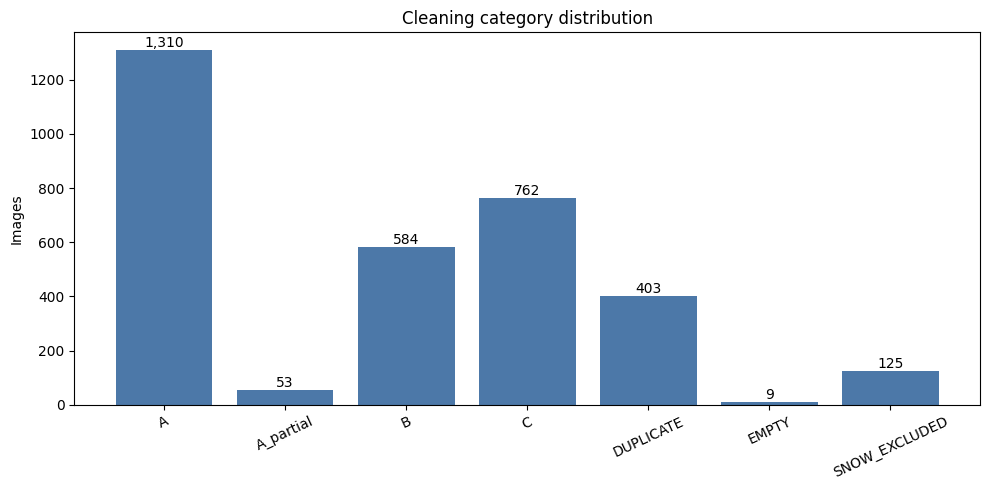

Saved for Medium: /content/drive/MyDrive/ai builders/figures/cleaning_category_distribution.png


In [12]:
category_table = (
    manifest.groupby(['source_dataset', 'final_category'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ALL_CATEGORIES, fill_value=0)
)

total_kept = int(manifest['kept_in_dataset'].sum())
total_excluded = int((~manifest['kept_in_dataset']).sum())

print('Category x Source breakdown:')
display(category_table)
print()
print(f'Total images: {len(manifest):,}')
print(f'  Kept:        {total_kept:,}')
print(f'  Excluded:    {total_excluded:,}')
print()
print('Kept by category:')
display(manifest.loc[manifest['kept_in_dataset'], 'final_category'].value_counts().rename_axis('final_category').reset_index(name='images'))


category_plot = (
    manifest['final_category']
    .value_counts()
    .reindex(ALL_CATEGORIES, fill_value=0)
)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(category_plot.index, category_plot.values, color='#4c78a8')
ax.set_title('Cleaning category distribution')
ax.set_ylabel('Images')
ax.tick_params(axis='x', rotation=25)
for bar, value in zip(bars, category_plot.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout()
cleaning_figure_path = FIG_DIR / 'cleaning_category_distribution.png'
fig.savefig(cleaning_figure_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved for Medium: {cleaning_figure_path}')


**คำอธิบายรูป:** หลัง cleaning เก็บภาพ A=1,310, A_partial=53, B=584 และ C=762 รวม 2,709 ภาพ โดย Category C ต้องใช้ SAM แปลง bbox ก่อน CVAT review


## เก็บ annotations ของภาพที่ผ่าน cleaning


In [13]:
kept_ids = set(manifest.loc[manifest['kept_in_dataset'], 'image_id'])

clean_annotations = annotations[annotations['image_id'].isin(kept_ids)].copy()
clean_annotations = clean_annotations[clean_annotations['class_unified'] != '_SKIP_'].copy()

clean_annotations = clean_annotations.merge(
    manifest[['image_id', 'source_dataset', 'final_category']],
    on='image_id',
    how='left',
    suffixes=('', '_manifest'),
)
if 'source_dataset_manifest' in clean_annotations.columns:
    clean_annotations['source_dataset'] = clean_annotations['source_dataset_manifest'].fillna(clean_annotations.get('source_dataset'))
    clean_annotations = clean_annotations.drop(columns=['source_dataset_manifest'])

annotation_cols = [
    'image_id',
    'annotation_id',
    'class_unified',
    'class_original',
    'format',
    'coords_normalized',
    'area_normalized',
    'source_dataset',
    'final_category',
]
annotation_cols = [c for c in annotation_cols if c in clean_annotations.columns]
clean_annotations = clean_annotations[annotation_cols].copy()

print(f'Annotations: {len(annotations):,} -> {len(clean_annotations):,}')
print()
print('Per class:')
display(clean_annotations['class_unified'].value_counts().rename_axis('class_unified').reset_index(name='annotations'))


Annotations: 35,037 -> 29,402

Per class:


,class_unified,annotations
0,panel_clean,10244
1,dust,5577
2,bird_drop,5325
3,panel_defective,2830
4,physical_damage,2760
5,leaf,2666


## ตรวจผล cleaning


In [14]:
actual_categories = set(manifest['final_category'].dropna().unique())
allowed_categories = set(ALL_CATEGORIES)
unexpected_categories = actual_categories - allowed_categories
assert not unexpected_categories, f'Unexpected categories: {sorted(unexpected_categories)}'

actual_kept_categories = set(
    manifest.loc[manifest['kept_in_dataset'], 'final_category'].unique()
)
assert actual_kept_categories <= KEPT_CATEGORIES

excluded_kept = manifest.loc[
    ~manifest['final_category'].isin(KEPT_CATEGORIES),
    'kept_in_dataset',
].any()
assert not excluded_kept, 'An excluded category is marked as kept'

assert set(clean_annotations['image_id']).issubset(kept_ids)
assert '_SKIP_' not in set(clean_annotations['class_unified'])

# จำนวนจาก cleaned dataset ชุดนี้ ใช้จับการเปลี่ยน category logic โดยไม่ตั้งใจ
EXPECTED_KEPT_COUNTS = {
    'A': 1310,
    'A_partial': 53,
    'B': 584,
    'C': 762,
}
actual_kept_counts = (
    manifest.loc[manifest['kept_in_dataset'], 'final_category']
    .value_counts()
    .to_dict()
)
assert actual_kept_counts == EXPECTED_KEPT_COUNTS, (
    f'Category counts changed: {actual_kept_counts}'
)

print('Cleaning checks passed')
print(f'  Kept categories : {actual_kept_counts}')
print(f'  Manifest rows   : {len(manifest):,}')
print(f'  Annotations     : {len(clean_annotations):,}')


Cleaning checks passed
  Kept categories : {'A': 1310, 'C': 762, 'B': 584, 'A_partial': 53}
  Manifest rows   : 3,246
  Annotations     : 29,402


## บันทึก manifest, annotations และ summary


In [15]:
manifest_cols = [
    'image_id',
    'source_dataset',
    'original_path',
    'original_split',
    'md5_hash',
    'duplicate_group_id',
    'is_duplicate',
    'is_exact_duplicate',
    'snow_image',
    'final_category',
    'kept_in_dataset',
    'exclusion_reason',
    'nested_defects',
    'orphan_defects',
    'panel_count',
    'defect_count',
    'nested_rate',
]
manifest_cols = [c for c in manifest_cols if c in manifest.columns]
output_manifest = manifest[manifest_cols].copy()

output_manifest.to_csv(OUTPUT_MANIFEST_PATH, index=False)
clean_annotations.to_csv(OUTPUT_ANNOTATIONS_PATH, index=False)

summary = {
    'description': 'Dataset categories for SAM and CVAT annotation',
    'input_manifest': str(active_input_manifest_path),
    'input_annotations': str(INPUT_ANNOTATIONS_PATH),
    'total_images': int(len(output_manifest)),
    'kept_images': int(total_kept),
    'excluded_images': int(total_excluded),
    'categories': {
        str(category): int(count)
        for category, count in output_manifest['final_category'].value_counts().items()
    },
    'category_by_source': {
        str(source): {
            str(category): int(count)
            for category, count in row.items()
        }
        for source, row in category_table.to_dict(orient='index').items()
    },
    'total_annotations': int(len(clean_annotations)),
    'class_counts': {
        str(class_name): int(count)
        for class_name, count in clean_annotations['class_unified'].value_counts().items()
    },
    'outputs': {
        'manifest': str(OUTPUT_MANIFEST_PATH),
        'annotations': str(OUTPUT_ANNOTATIONS_PATH),
        'summary': str(OUTPUT_SUMMARY_PATH),
    },
}

with open(OUTPUT_SUMMARY_PATH, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

for path in [OUTPUT_MANIFEST_PATH, OUTPUT_ANNOTATIONS_PATH, OUTPUT_SUMMARY_PATH]:
    assert path.exists(), f'Missing saved output: {path}'

print(f'Saved: {OUTPUT_MANIFEST_PATH}')
print(f'Saved: {OUTPUT_ANNOTATIONS_PATH}')
print(f'Saved: {OUTPUT_SUMMARY_PATH}')


Saved: /content/drive/MyDrive/ai builders/dataset/cleaned_v4/final_manifest_v4.csv
Saved: /content/drive/MyDrive/ai builders/dataset/cleaned_v4/clean_annotations.csv
Saved: /content/drive/MyDrive/ai builders/dataset/cleaned_v4/summary_v4.json


## สรุป

เก็บภาพสำหรับ annotation รวม 2,709 ภาพ: A=1,310, A_partial=53, B=584 และ C=762 ส่วน duplicate, empty และ snow images ถูกกันออกตามกฎเดิม


In [16]:
category_counts = output_manifest['final_category'].value_counts().to_dict()

print('Cleaning summary')
print(f'  Total images : {len(output_manifest):,}')
print(f'  Kept images  : {total_kept:,}')
print(f'  Excluded     : {total_excluded:,}')
print(f'  Categories   : {category_counts}')
print(f'  Annotations  : {len(clean_annotations):,}')
print(f'  Output folder: {OUTPUT_BASE}')


Cleaning summary
  Total images : 3,246
  Kept images  : 2,709
  Excluded     : 537
  Categories   : {'A': 1310, 'C': 762, 'B': 584, 'DUPLICATE': 403, 'SNOW_EXCLUDED': 125, 'A_partial': 53, 'EMPTY': 9}
  Annotations  : 29,402
  Output folder: /content/drive/MyDrive/ai builders/dataset/cleaned_v4
